## Assignment 3: LLMs and Machine Learning

#### Tasks 0-2: I didn't have time to get the Ollama to work unfortunately so I only did task 3.

### Task 3: Supervised machine learning 

#### A: Import the dataset and conduct exploratory data analysis on it

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loads the dataset using ; delimiter
df = pd.read_csv("bank-additional.csv", sep=";")

df.info()
display(df.head())
display(df.describe())
print(df["y"].value_counts()) #counts yes / no rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


y
no     3668
yes     451
Name: count, dtype: int64


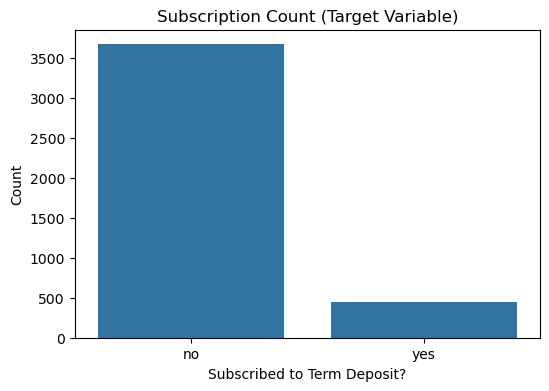

In [20]:
# Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Subscription Count (Target Variable)")
plt.xlabel("Subscribed to Term Deposit?")
plt.ylabel("Count")
plt.show()

#### B: Preprocess the data using the appropriate methods as described in the course materials

In [29]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

df_processed = df.copy()

# Encodes target variable: "yes" -> 1, "no" -> 0
df_processed["y"] = df_processed["y"].map({"yes": 1, "no": 0})

# One-hot encoding for marital (categorical with no order)
df_processed = pd.get_dummies(df_processed, columns=["marital"], drop_first=True, dtype=float)

# Label encoding for other text columns
le = LabelEncoder()
text_cols = ["job", "education", "default", "housing", "loan", 
             "contact", "month", "day_of_week", "poutcome"]
for col in text_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# Standardization for numeric columns
scaler = StandardScaler()
df_processed[["age", "duration", "campaign", "pdays", "previous",
              "emp.var.rate", "cons.price.idx", "cons.conf.idx", 
              "euribor3m", "nr.employed"]] = scaler.fit_transform(
    df_processed[["age", "duration", "campaign", "pdays", "previous",
                  "emp.var.rate", "cons.price.idx", "cons.conf.idx", 
                  "euribor3m", "nr.employed"]]
)

display(df_processed.head())

,age,job,education,default,housing,loan,contact,month,day_of_week,duration,...,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,marital_married,marital_single,marital_unknown
0,-0.980752,1,2,0,2,0,0,6,0,0.903952,...,1,-1.206054,-1.185448,-1.240939,-1.331707,-0.914779,0,1.0,0.0,0.0
1,-0.107991,7,3,0,0,0,1,6,0,0.350300,...,1,0.649441,0.715193,0.892269,0.711698,0.332862,0,0.0,1.0,0.0
2,-1.465619,7,3,0,2,0,1,4,4,-0.116966,...,1,0.841389,1.528273,-0.283172,0.773427,0.836535,0,1.0,0.0,0.0
3,-0.204965,7,2,0,1,1,1,4,0,-0.941553,...,1,0.841389,1.528273,-0.283172,0.771697,0.836535,0,1.0,0.0,0.0
4,0.667795,0,6,0,2,0,0,7,1,-0.780563,...,1,-0.118350,-0.655478,-0.326707,0.328632,0.398028,0,1.0,0.0,0.0


#### C: Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Splits features and target
X = df_processed.drop(columns=["y"])
y = df_processed["y"]

# Train-validation-test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 2471
Validation size: 824
Test size: 824


In [31]:
# Trains 3 models
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_val)

# SVM
svm = SVC(random_state=42, class_weight="balanced")
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_val)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)

In [32]:
# Evaluates on validation set
for name, y_pred in [("Logistic Regression", y_pred_lr), 
                     ("SVM", y_pred_svm), 
                     ("Random Forest", y_pred_rf)]:
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred):.4f}")
    print()

--- Logistic Regression ---
Accuracy:  0.9138
Precision: 0.7447
Recall:    0.3723
F1-score:  0.4965

--- SVM ---
Accuracy:  0.8580
Precision: 0.4392
Recall:    0.8830
F1-score:  0.5866

--- Random Forest ---
Accuracy:  0.9078
Precision: 0.6500
Recall:    0.4149
F1-score:  0.5065



#### 
This is a classification task as we predict yes or no (subscribed or not). I chose Logistic Regression as a simple baseline, SVM because it handles imbalanced classes well with class_weight="balanced", and Random Forest because it handles mixed data types well.

#### D: Compare using train, validation and test set split versus using cross-validation. Which one performs better?

In [37]:
from sklearn.model_selection import cross_val_score

# Cross-validation for all 3 models
for name, model in [("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
                    ("SVM", SVC(random_state=42, class_weight="balanced")),
                    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42))]:
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="recall")
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Logistic Regression: 0.4103 (+/- 0.0360)
SVM: 0.8737 (+/- 0.0316)
Random Forest: 0.4058 (+/- 0.0311)


#### 
Cross-validation is more reliable than train/val/test split because it tests on all parts of the data across 5 rounds. It reduces the chance of a lucky or unlucky split. 

#### E: Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Tune hyperparameters using GridSearch on Random Forest
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "bootstrap": [True, False]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), 
                       param_grid_rf, cv=5, scoring="recall", n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Best RF parameters:", grid_rf.best_params_)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Final evaluation on test set
final_models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest (tuned)": grid_rf.best_estimator_
}

for name, model in final_models.items():
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
    print()

In [ ]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, final_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues")
    ax.set_title(name)

plt.suptitle("Confusion Matrices on Test Set")
plt.tight_layout()
plt.show()

#### 

The dataset is imbalanced because it has way more "no" than "yes", so recall is the most important metric to identify people who will subscribe.

SVM with class_weight="balanced" worked best, Random Forest after tuning also worked well and Logistic Regression was the simplest but worst on recall.